Nama : Untara Eka Saputra

Kelas : IK - 3D

NIM : 3.34.23.3.24

# **Praktikum 1. Transormasi Kurva (Citra Negatif)**

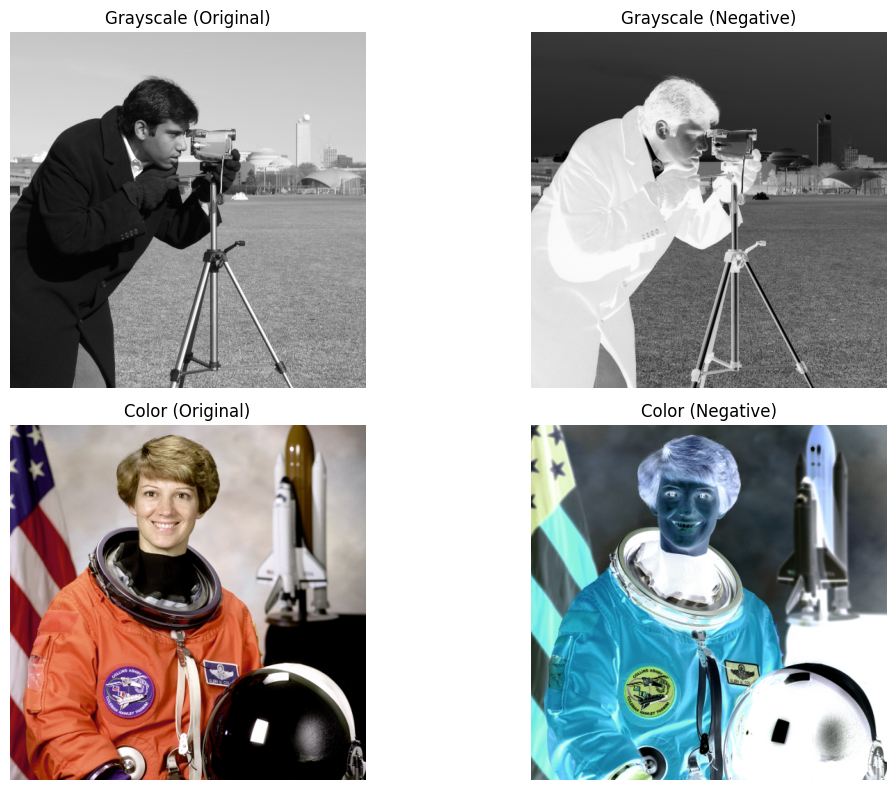

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ============================
# 1. TRANSFORMASI NEGATIF GRAYSCALE
# ============================
# Ambil citra grayscale (0–255)
image_gray_uint8 = data.camera()

# Konversi ke float (0–1)
image_gray_float = img_as_float(image_gray_uint8)

# Inversi intensitas
negative_gray = 1.0 - image_gray_float


# ============================
# 2. TRANSFORMASI NEGATIF RGB
# ============================
# Ambil citra berwarna (RGB)
image_color_uint8 = data.astronaut()

# Konversi ke float (0–1)
image_color_float = img_as_float(image_color_uint8)

# Inversi tiap channel RGB
negative_color = 1.0 - image_color_float


# ============================
# 3. VISUALISASI HASIL
# ============================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Grayscale - Original
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

# Grayscale - Negative
axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# RGB - Original
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

# RGB - Negative
axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# **Praktikum 2. Histogram dan Ekualisasi Histogram**

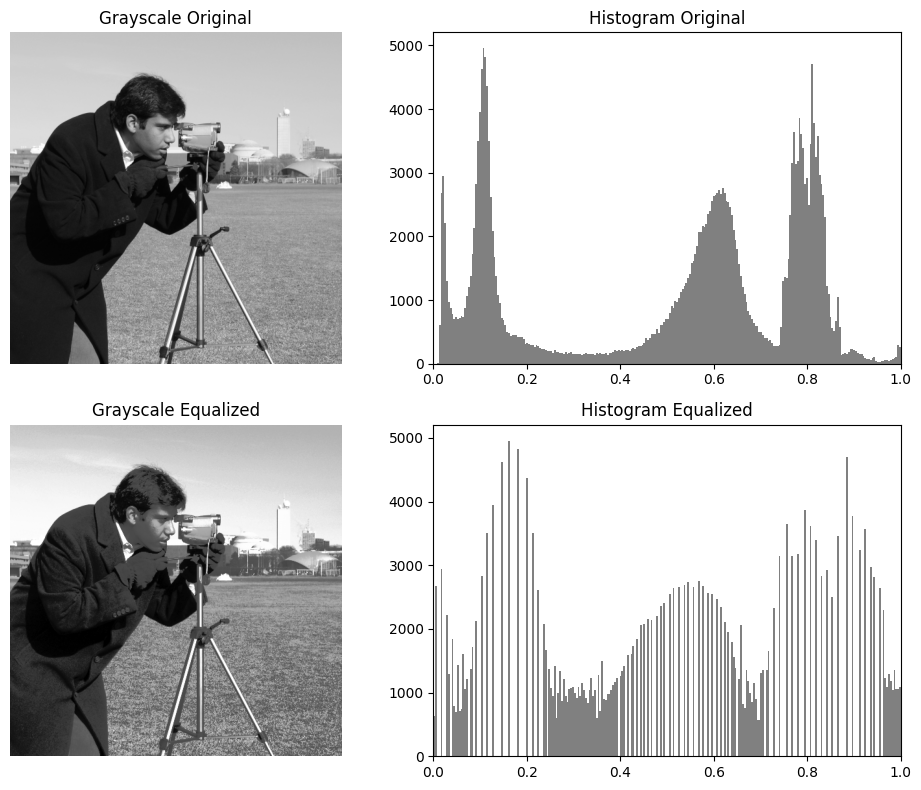

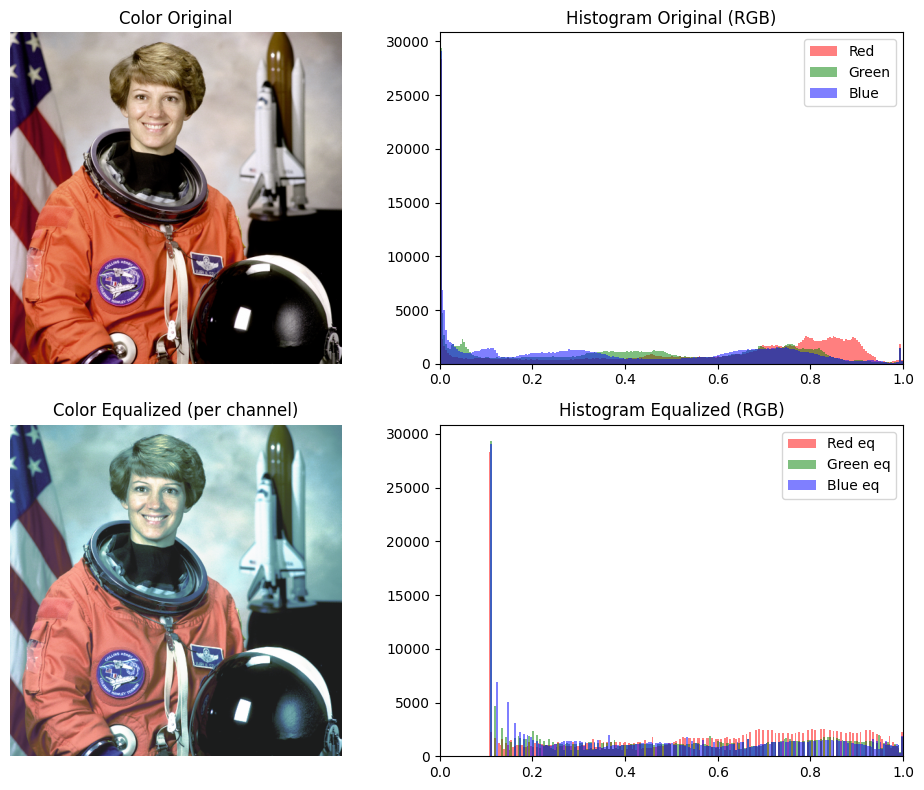

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# =========================================
# BAGIAN 1: HISTOGRAM & EKUALISASI (GRAYSCALE)
# =========================================

# Load citra grayscale
image_gray = img_as_float(data.camera())

# Histogram citra asli
hist_gray, _ = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, _ = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# Visualisasi grayscale
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Original image
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# Original histogram
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# Equalized image
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# Equalized histogram
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


# =========================================
# BAGIAN 2: HISTOGRAM & EKUALISASI (RGB)
# =========================================

# Load citra warna
image_color = img_as_float(data.astronaut())

# Pisahkan channel RGB
r = image_color[:, :, 0]
g = image_color[:, :, 1]
b = image_color[:, :, 2]

# Histogram masing-masing channel
hist_r, _ = np.histogram(r.ravel(), bins=256, range=(0, 1))
hist_g, _ = np.histogram(g.ravel(), bins=256, range=(0, 1))
hist_b, _ = np.histogram(b.ravel(), bins=256, range=(0, 1))

# Ekualisasi tiap channel
r_eq = exposure.equalize_hist(r)
g_eq = exposure.equalize_hist(g)
b_eq = exposure.equalize_hist(b)

# Gabungkan kembali
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Visualisasi RGB
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# Original image
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# Original histogram
axes2[0, 1].hist(r.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend()

# Equalized image
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# Equalized histogram
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend()

plt.tight_layout()
plt.show()

# **Praktikum 3. Konvolusi (Filter Rata-rata)**

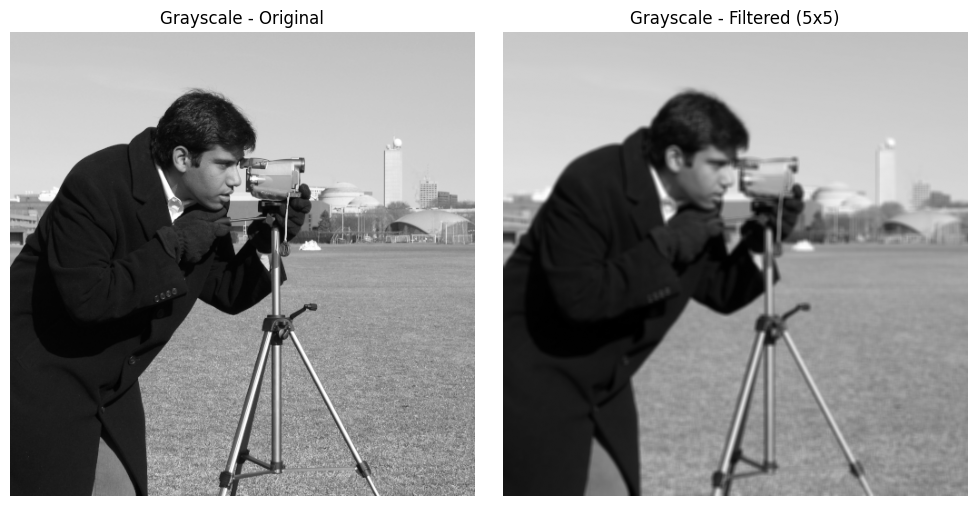

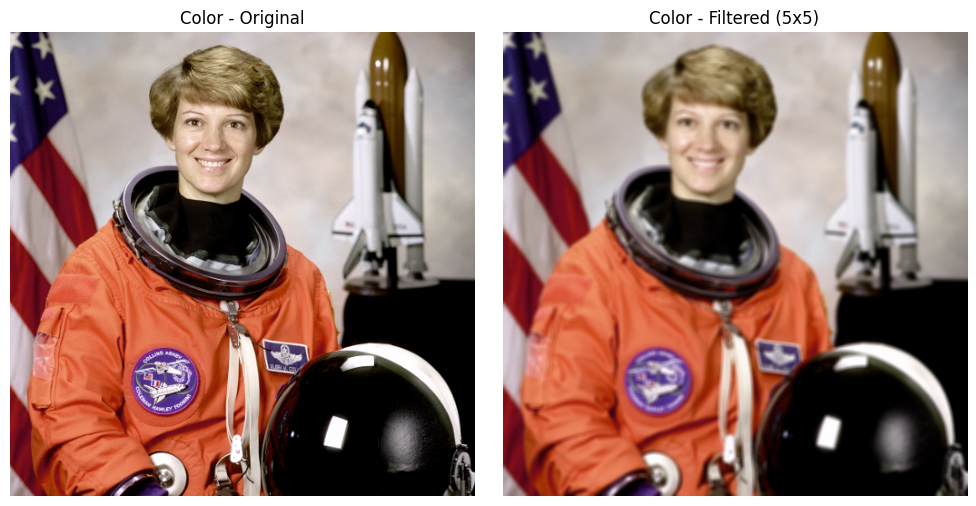

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# =========================================
# 1) FILTER RATA-RATA (GRAYSCALE)
# =========================================

# Load citra grayscale
gray_img = img_as_float(data.camera())

# Definisi kernel rata-rata (misal 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size ** 2)

# Konvolusi (filtering)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size})")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# =========================================
# 2) FILTER RATA-RATA (RGB)
# =========================================

# Load citra warna
color_img = img_as_float(data.astronaut())

# Siapkan array hasil
color_filtered = np.zeros_like(color_img)

# Filtering tiap channel RGB
for c in range(3):
    color_filtered[:, :, c] = ndi.convolve(
        color_img[:, :, c], kernel, mode='reflect'
    )

# Visualisasi
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size})")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

# **Praktikum 4. Filter Median (penghilangan noise/derau)**

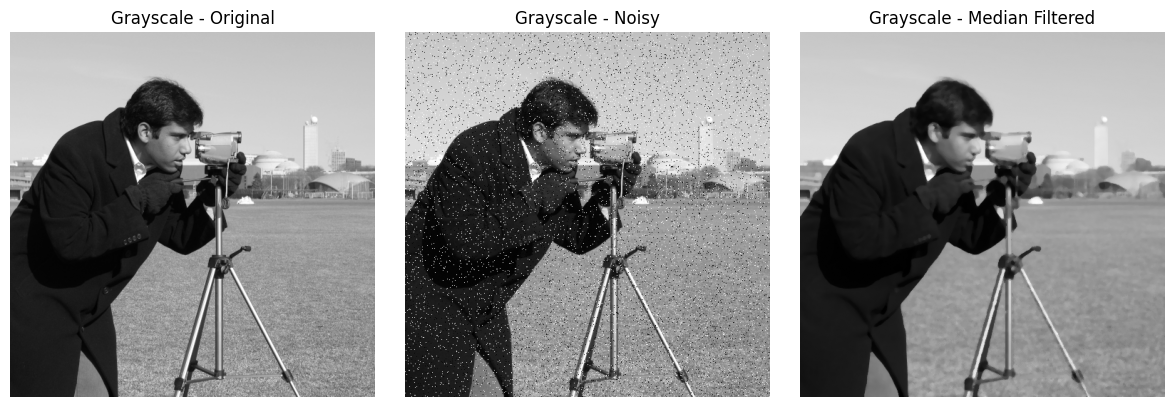

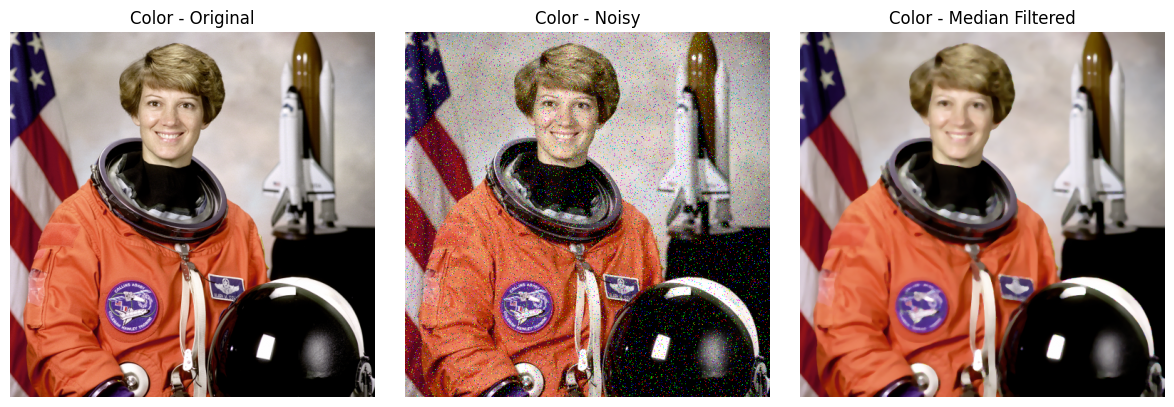

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# =========================================
# 1) FILTER MEDIAN (GRAYSCALE)
# =========================================

# Load citra grayscale
gray = img_as_float(data.camera())

# Tambahkan noise salt & pepper
gray_noisy = util.random_noise(gray, mode='s&p', amount=0.05)

# Median filter (disk radius 3)
selem = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, selem)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()


# =========================================
# 2) FILTER MEDIAN (RGB)
# =========================================

# Load citra warna
color = img_as_float(data.astronaut())

# Tambahkan noise salt & pepper
color_noisy = util.random_noise(color, mode='s&p', amount=0.05)

# Median filter per channel
color_denoised = np.zeros_like(color_noisy)

for c in range(3):
    color_denoised[:, :, c] = filters.median(
        color_noisy[:, :, c],
        morphology.disk(3)
    )

# Visualisasi
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))

axes2[0].imshow(color)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

# **Eksperimen Transformasi Intensitas Lain**

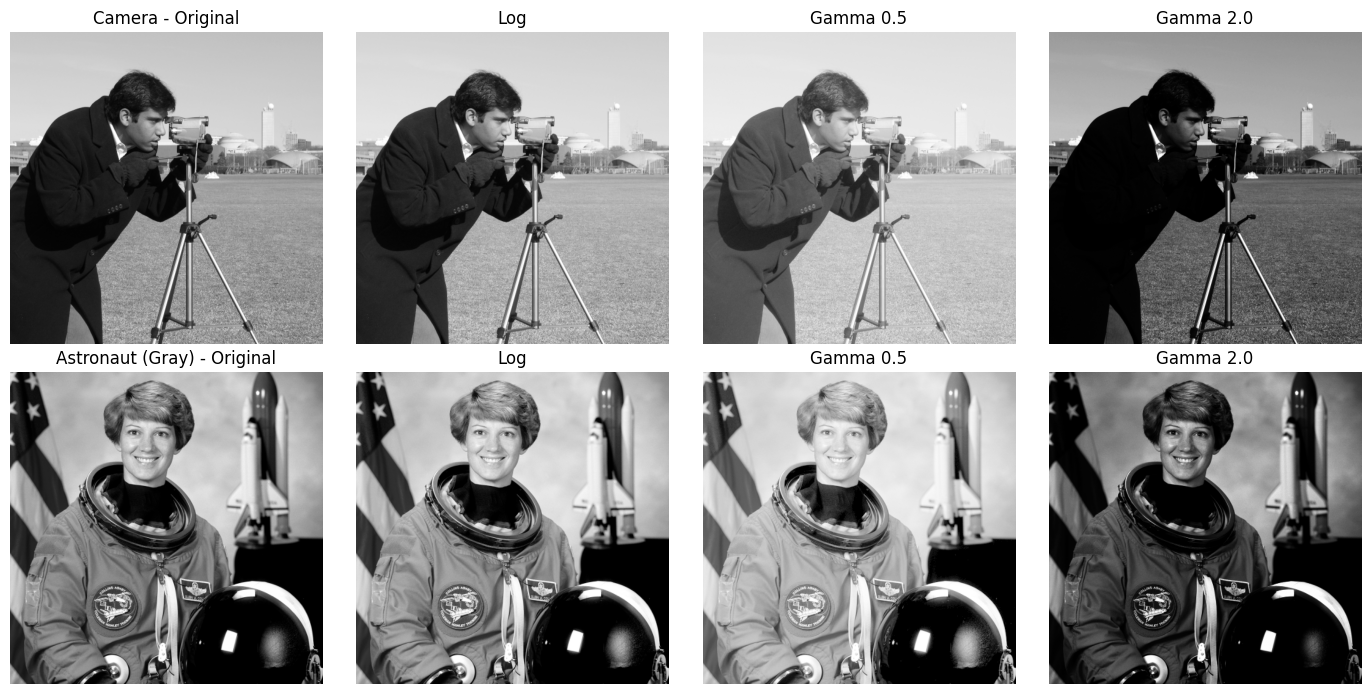

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float, exposure

# =========================================
# LOAD 2 CITRA GRAYSCALE
# =========================================

# Citra 1: camera
img1 = img_as_float(data.camera())

# Citra 2: astronaut → grayscale
img2 = img_as_float(color.rgb2gray(data.astronaut()))

# =========================================
# TRANSFORMASI
# =========================================

def log_transform(img, c=1.0):
    result = c * np.log(1 + img)
    return result / np.max(result)

def gamma_transform(img, gamma):
    return exposure.adjust_gamma(img, gamma=gamma)

# Terapkan ke kedua citra
images = [img1, img2]
titles = ["Camera", "Astronaut (Gray)"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, img in enumerate(images):
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"{titles[i]} - Original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(log_transform(img), cmap='gray')
    axes[i, 1].set_title("Log")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(gamma_transform(img, 0.5), cmap='gray')
    axes[i, 2].set_title("Gamma 0.5")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(gamma_transform(img, 2.0), cmap='gray')
    axes[i, 3].set_title("Gamma 2.0")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

# **Perbandingan Metode Peningkatan Kontras**

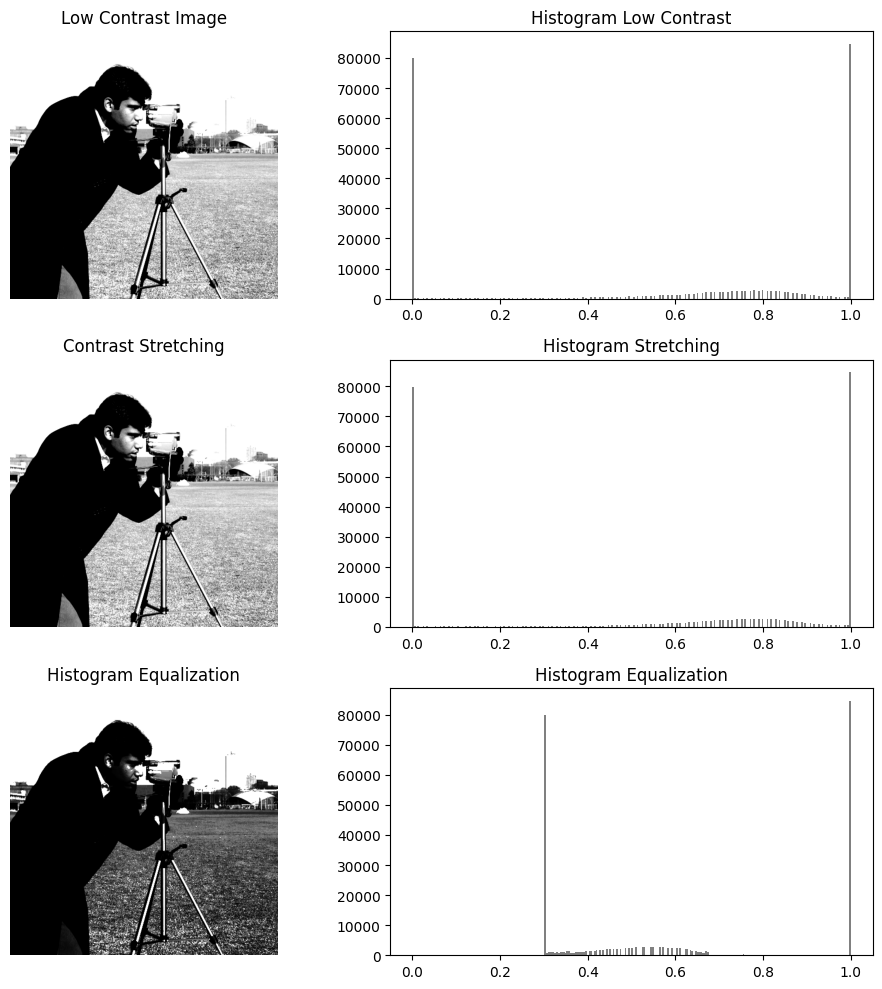

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# =========================================
# 1) LOAD CITRA & BUAT KONTRAS RENDAH
# =========================================

# Ambil citra grayscale
image = img_as_float(data.camera())

# Simulasi citra kontras rendah (dipersempit range intensitasnya)
low_contrast = exposure.rescale_intensity(image, in_range=(0.3, 0.7))

# =========================================
# 2) METODE 1: CONTRAST STRETCHING
# =========================================

p2, p98 = np.percentile(low_contrast, (2, 98))
stretch = exposure.rescale_intensity(low_contrast, in_range=(p2, p98))

# =========================================
# 3) METODE 2: HISTOGRAM EQUALIZATION
# =========================================

equalized = exposure.equalize_hist(low_contrast)

# =========================================
# 4) VISUALISASI
# =========================================

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

# Original low contrast
axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title("Low Contrast Image")
axes[0, 0].axis('off')

axes[0, 1].hist(low_contrast.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Low Contrast")

# Contrast stretching
axes[1, 0].imshow(stretch, cmap='gray')
axes[1, 0].set_title("Contrast Stretching")
axes[1, 0].axis('off')

axes[1, 1].hist(stretch.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Stretching")

# Histogram equalization
axes[2, 0].imshow(equalized, cmap='gray')
axes[2, 0].set_title("Histogram Equalization")
axes[2, 0].axis('off')

axes[2, 1].hist(equalized.ravel(), bins=256, range=(0,1), color='gray')
axes[2, 1].set_title("Histogram Equalization")

plt.tight_layout()
plt.show()

# **Filter Median vs Filter Rata-rata**

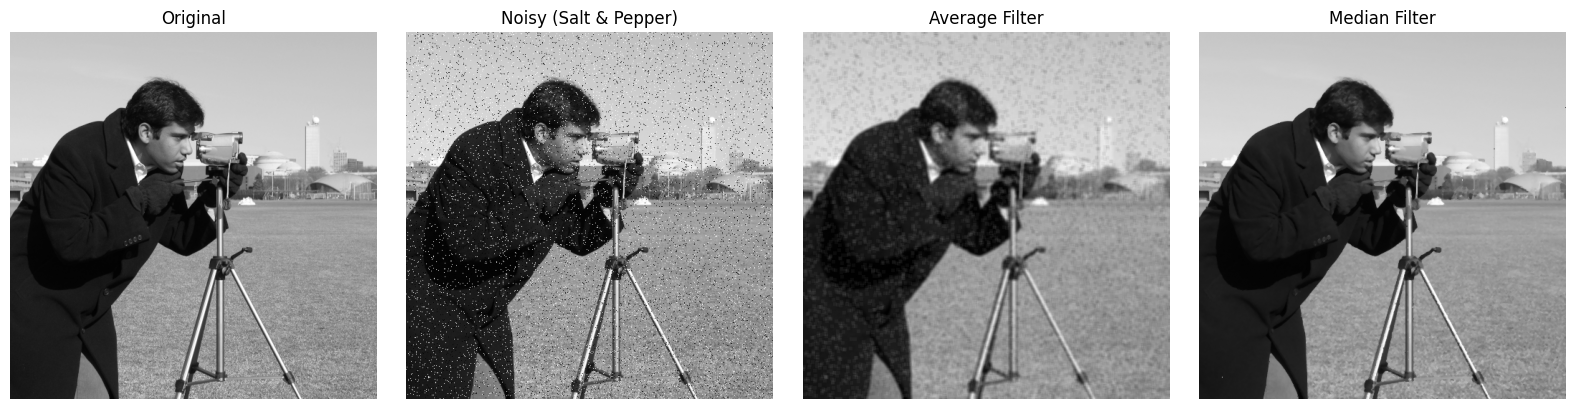

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, img_as_float
from scipy import ndimage as ndi

# =========================================
# 1) LOAD CITRA & TAMBAH NOISE
# =========================================

image = img_as_float(data.camera())

# Tambahkan noise salt & pepper
noisy = util.random_noise(image, mode='s&p', amount=0.05)

# =========================================
# 2) FILTER RATA-RATA (AVERAGE)
# =========================================

kernel_size = 5
kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)

avg_filtered = ndi.convolve(noisy, kernel, mode='reflect')

# =========================================
# 3) FILTER MEDIAN
# =========================================

median_filtered = filters.median(noisy)

# =========================================
# 4) VISUALISASI
# =========================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(avg_filtered, cmap='gray')
axes[2].set_title("Average Filter")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Median Filter")
axes[3].axis('off')

plt.tight_layout()
plt.show()